In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.manifold import TSNE 
import matplotlib.pyplot as plt 
import seaborn as sns 
from keras.layers import Input, Dense 
from keras.models import Model, Sequential 
from keras import regularizers 
from sklearn.preprocessing import LabelEncoder

# Extração de Texto
from nltk.corpus import stopwords
import nltk
import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")



In [2]:
# Loading the dataset 
df = pd.read_csv('./cor_da_justica.csv')   

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [5]:
df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates()
df = df.dropna(subset=["ementa"])

In [6]:
df['cor'].value_counts()

cor
BRANCA    3711
OUTROS    1532
Name: count, dtype: int64

In [7]:
# brancos = df.loc[df['cor'] == "BRANCA" ][:1532]
# outros = df.loc[df['cor'] == 'OUTROS' ][:1532]

# df = pd.concat([brancos, outros])


In [8]:
df

,ementa,ementaDetalhada,ano,keywords,uris.uriAutores,uris.uriPropPrincipal,uris.uriUltimoRelator,nome,cpf,foto,...,uris.uriPartido,ementa_principal,situacao,tipo,keywords_principal,nome_partido,sigla_partido,status_partido,total_membros_partido,cor
0,Garante ao acertador de qualquer tipo de jogo ...,NaN,2003,"Garantia, omissão, identificação, ganhador, lo...",https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/prop...,https://dadosabertos.camara.leg.br/api/v2/depu...,ANDRES NAVARRO SANCHEZ,7078570820,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,"Acrescenta art. 10-B à Lei n° 9.613, de 3 de m...",Aguardando Parecer,Projeto de Lei,"Alteração, Lei de Lavagem de Dinheiro, obrigat...",Partido da República,PR,Inativo,0,BRANCA
1,Institui o dia 02 de julho como data histórica...,NaN,2003,"Criação, Dia Nacional da Independência do Bras...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,DOUGLAS DE PAULO VIEGAS,25519061807,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Socialismo e Liberdade,PSOL,Ativo,13,OUTROS
2,Regulamenta o § 7º do art. 37 da Constituição ...,Fixa um período de impedimento ou quarentena d...,2003,"Regulamentação, Constituição Federal, requisit...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,GILSON MARQUES VIEIRA,824207939,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Socialismo e Liberdade,PSOL,Ativo,13,BRANCA
3,"Altera dispositivos da Lei nº 9.648, de 27 de ...",NaN,2003,"Alteração, lei federal, aumento, percentual, c...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,ADRIANA MIGUEL VENTURA,12519851813,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Socialista Brasileiro,PSB,Ativo,14,BRANCA
4,"Modifica a redação do art. 7º da Lei nº 9.709,...",Estabelece que no desmembramento de Estados e ...,2003,"Alteração, Lei da Soberania Popular, definição...",https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,https://dadosabertos.camara.leg.br/api/v2/depu...,ALFREDO GASPAR DE MENDONÇA NETO,72503017487,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido da República,PR,Inativo,0,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5368,"Requer informações ao Senhor André Fufuca, Min...",NaN,2024,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,DOUGLAS DE PAULO VIEGAS,25519061807,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,União Brasil,UNIÃO,Ativo,58,OUTROS
5369,"Parecer do Relator, Dep. Luiz Philippe de Orle...",NaN,0,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,LUIZ PHILIPPE DE ORLEANS BRAGANÇA,11844856828,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Liberal,PL,Ativo,95,BRANCA
5371,Dispõe sobre a retirada de invasores de propri...,NaN,0,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,VICTOR GAROZI LINHALIS,10204305756,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Podemos,PODE,Ativo,15,BRANCA
5372,Requer realização de mesa redonda na EXPOIMP 2...,NaN,2024,NaN,https://dadosabertos.camara.leg.br/api/v2/prop...,NaN,NaN,MARCIO JOSE HONAISER,27848779300,https://www.camara.leg.br/internet/deputado/ba...,...,https://dadosabertos.camara.leg.br/api/v2/part...,vazio,NaN,NaN,NaN,Partido Democrático Trabalhista,PDT,Ativo,18,BRANC

In [9]:
# nltk.download('stopwords')

In [10]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


In [11]:
X = X.toarray()

In [12]:

def tsne_plot(x, y): 
      
    # Setting the plotting background 
    sns.set_theme(style ="whitegrid") 
      
    tsne = TSNE(n_components = 2, random_state = 0) 
      
    # Reducing the dimensionality of the data 
    X_transformed = tsne.fit_transform(x) 

    plt.figure(figsize =(12, 8)) 
      
    # Building the scatter plot 
    plt.scatter(X_transformed[np.where(y == 0), 0],  
                X_transformed[np.where(y == 0), 1], 
                marker ='o', color ='y', linewidth =1, 
                alpha = 0.8, label ='Brancos') 
    plt.scatter(X_transformed[np.where(y == 1), 0], 
                X_transformed[np.where(y == 1), 1], 
                marker ='o', color ='r', linewidth =1, 
                alpha = 0.8, label ='Outros') 
  
    # Specifying the location of the legend 
    plt.legend(loc ='best') 
      
    # Plotting the reduced data 
    plt.show() 

In [13]:
lab = LabelEncoder()
y = lab.fit_transform(df['cor'])

In [14]:
y

array([0, 1, 0, ..., 0, 0, 0])

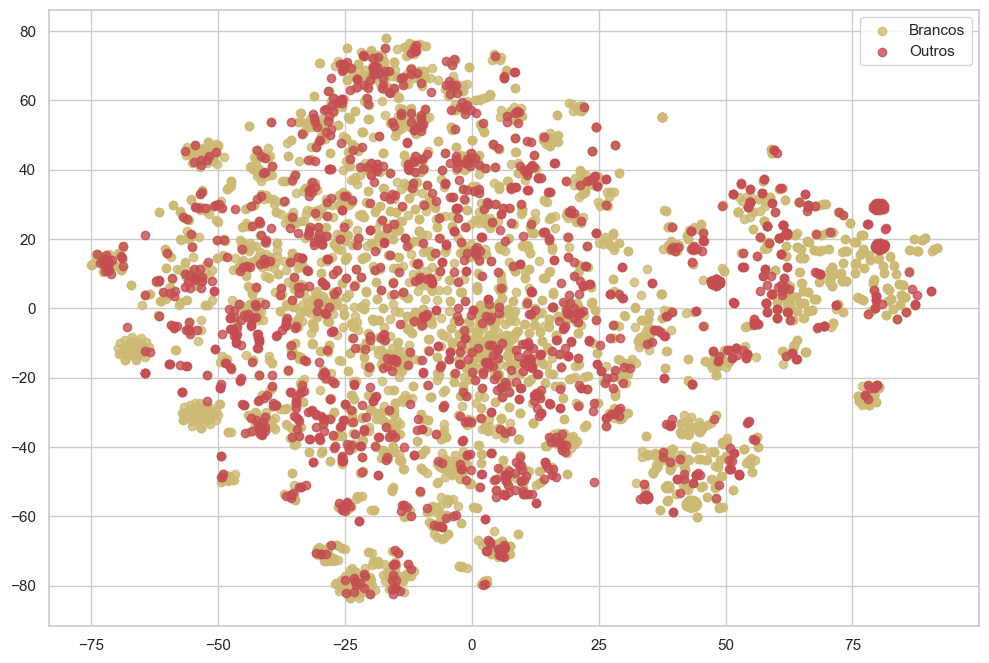

In [15]:

tsne_plot(X, y) 

In [16]:

# Scaling the data to make it suitable for the auto-encoder 
X_scaled = MinMaxScaler().fit_transform(X) 
X_normal_scaled = X_scaled[y == 0] 
X_fraud_scaled = X_scaled[y == 1] 

In [17]:
# Building the Input Layer 
input_layer = Input(shape =(X.shape[1], )) 

# Building the Encoder network 
encoded = Dense(100, activation ='tanh', 
				activity_regularizer = regularizers.l1(10e-5))(input_layer) 
encoded = Dense(50, activation ='tanh', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(25, activation ='tanh', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(12, activation ='tanh', 
				activity_regularizer = regularizers.l1(10e-5))(encoded) 
encoded = Dense(6, activation ='relu')(encoded) 

# Building the Decoder network 
decoded = Dense(12, activation ='tanh')(encoded) 
decoded = Dense(25, activation ='tanh')(decoded) 
decoded = Dense(50, activation ='tanh')(decoded) 
decoded = Dense(100, activation ='tanh')(decoded) 

# Building the Output Layer 
output_layer = Dense(X.shape[1], activation ='relu')(decoded) 


In [26]:
X_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [27]:

# Defining the parameters of the Auto-encoder network 
autoencoder = Model(input_layer, output_layer) 
autoencoder.compile(optimizer ="adadelta", loss ="mse") 
  
# Training the Auto-encoder network 
autoencoder.fit(X_scaled, X_scaled,  
                batch_size = 16, epochs = 10,  
                shuffle = True, validation_split = 0.20) 

Epoch 1/10
263/263 [==============================] - 10s 26ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 2/10
263/263 [==============================] - 6s 23ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 4/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 5/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 6/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 7/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 8/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 10/10
263/263 [==============================] - 6s 22ms/step - loss: 0.0013 - val_l

In [28]:

hidden_representation = Sequential() 
hidden_representation.add(autoencoder.layers[0]) 
hidden_representation.add(autoencoder.layers[1]) 
hidden_representation.add(autoencoder.layers[2]) 
hidden_representation.add(autoencoder.layers[3]) 
hidden_representation.add(autoencoder.layers[4]) 

48/48 [==============================] - 0s 4ms/step


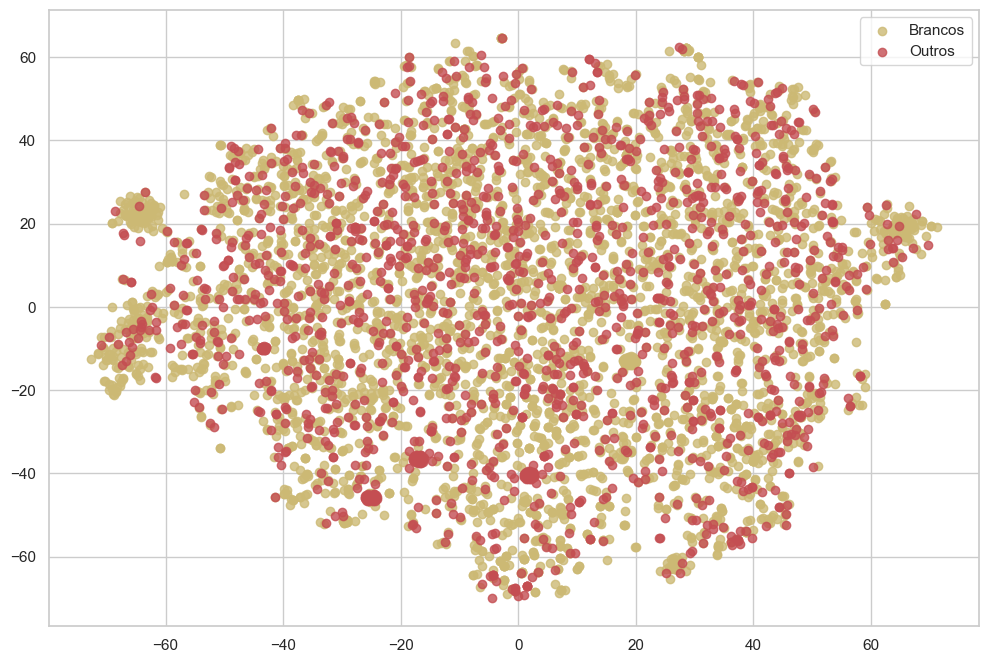

In [29]:
# Separating the points encoded by the Auto-encoder as normal and fraud 
normal_hidden_rep = hidden_representation.predict(X_normal_scaled) 
fraud_hidden_rep = hidden_representation.predict(X_fraud_scaled) 
  
# Combining the encoded points into a single table  
encoded_X = np.append(normal_hidden_rep, fraud_hidden_rep, axis = 0) 
y_normal = np.zeros(normal_hidden_rep.shape[0]) 
y_fraud = np.ones(fraud_hidden_rep.shape[0]) 
encoded_y = np.append(y_normal, y_fraud) 
  
# Plotting the encoded points 
tsne_plot(encoded_X, encoded_y) 

In [30]:

# Splitting the encoded data for linear classification 
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(encoded_X, encoded_y, test_size = 0.2) 
  
# Splitting the original data for non-linear classification 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2) 

In [31]:
# Building the logistic regression model 
lrclf = LogisticRegression() 
lrclf.fit(X_train_encoded, y_train_encoded) 
  
# Storing the predictions of the linear model 
y_pred_lrclf = lrclf.predict(X_test_encoded) 
  
# Evaluating the performance of the linear model 
print('Accuracy : '+str(accuracy_score(y_test_encoded, y_pred_lrclf))) 

Accuracy : 0.7073403241182078


In [32]:

# # Building the SVM model 
# svmclf = SVC() 
# svmclf.fit(X_train, y_train) 
  
# # Storing the predictions of the non-linear model 
# y_pred_svmclf = svmclf.predict(X_test) 
  
# # Evaluating the performance of the non-linear model 
# print('Accuracy : '+str(accuracy_score(y_test, y_pred_svmclf))) 